<a href="https://colab.research.google.com/github/vanesamrd/PCVK_Ganjil_2026/blob/main/P6_25_VANESA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
NAMA = 'Vanesa Mardiana Putri'
NIM  = '244107020129'
print(NAMA, NIM)

Vanesa Mardiana Putri 244107020129


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv
import math
from google.colab.patches import cv2_imshow
from PIL import Image as im

In [5]:
def convolution2d(image, kernel, stride, padding):
    image_pad = np.pad(image, ((padding, padding), (padding, padding)),
                       mode='constant', constant_values=0)
    img_h, img_w = image_pad.shape
    k_h, k_w = kernel.shape

    out_h = (img_h - k_h) // stride + 1
    out_w = (img_w - k_w) // stride + 1
    output = np.zeros((out_h, out_w), dtype=np.float32)

    for x in range(out_h):
        for y in range(out_w):
            z = np.sum(kernel * image_pad[x*stride:x*stride+k_h, y*stride:y*stride+k_w])
            output[x, y] = z

    return np.clip(output, 0, 255).astype(np.uint8)

In [6]:
img = cv.imread('/content/drive/MyDrive/pcvk_vanesa/Images/mandrill.tiff')
img_gray = cv.cvtColor(img,cv.COLOR_BGR2GRAY)

In [7]:
kernel_sharpen = np.array([[0,-1,0],
                           [-1,5,-1],
                           [0,-1,0]])

array([[  0,   0,   0, ...,   0,   0,   0],
       [  0, 255,   0, ..., 255, 255,   0],
       [  0, 255, 179, ..., 249, 218,   0],
       ...,
       [  0, 255, 255, ..., 159, 183,   0],
       [  0,   0,   0, ...,   0,   0,   0],
       [  0,   0,   0, ...,   0,   0,   0]], dtype=uint8)
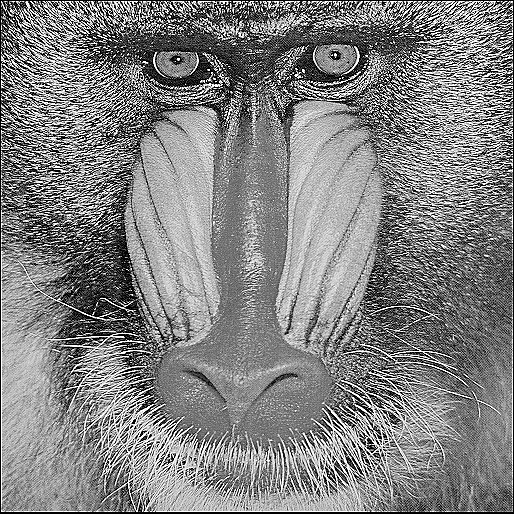

In [8]:
convolution2d(img_gray,kernel_sharpen,1,2)

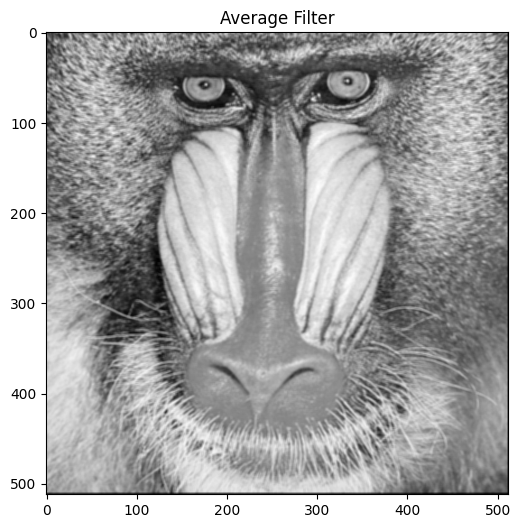

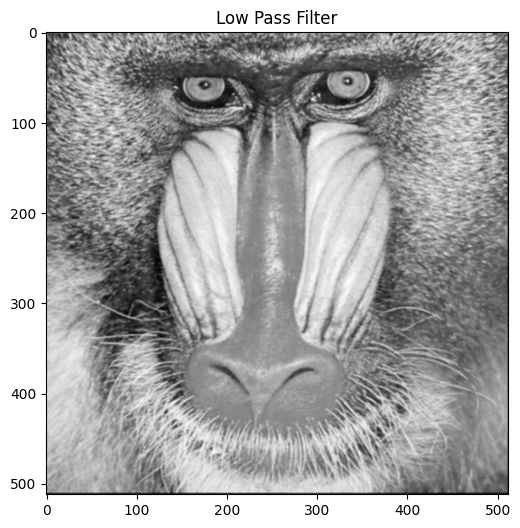

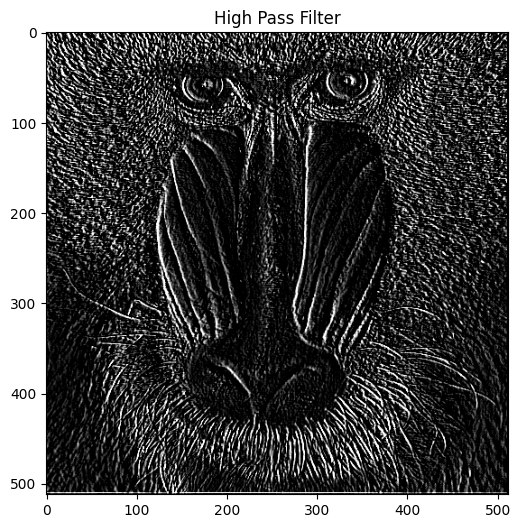

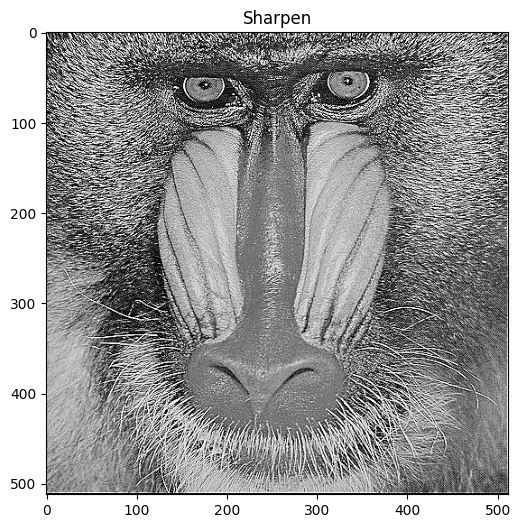

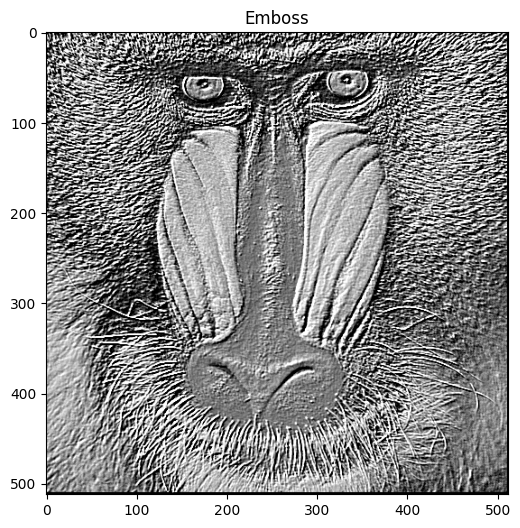

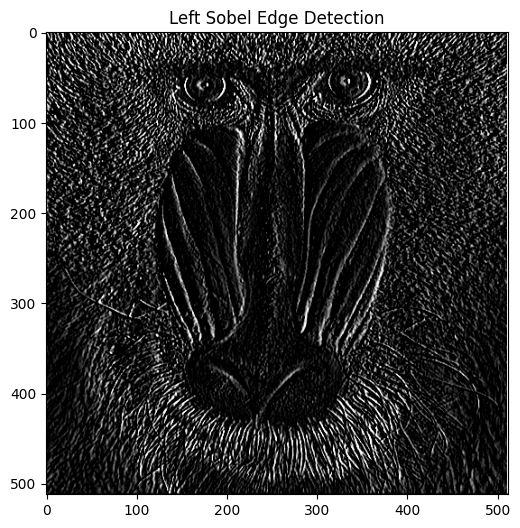

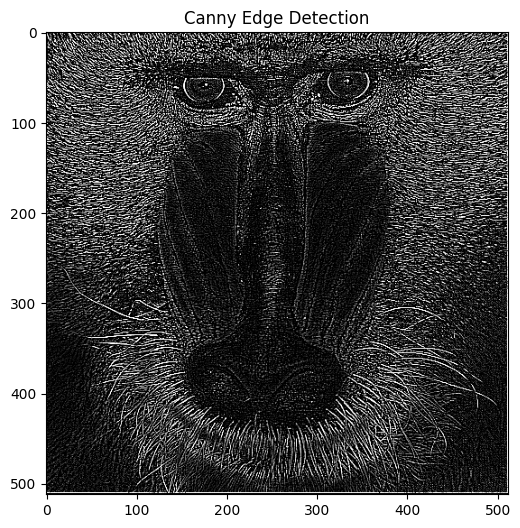

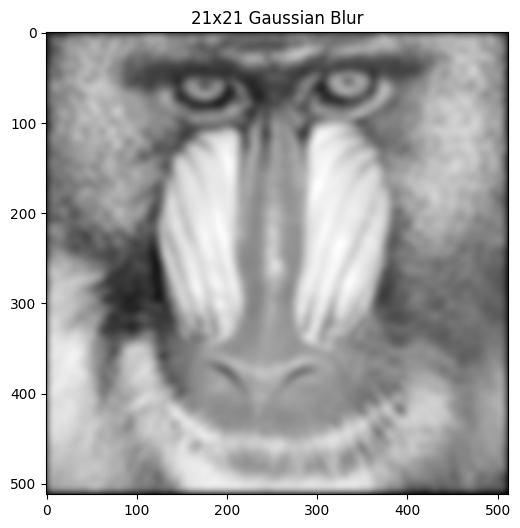

In [9]:
kernel_average = np.ones((3,3)) / 9
kernel_lowpass = np.array([[1,1,1],
                           [1,4,1],
                           [1,1,1]]) / 12
kernel_highpass = np.array([[-1,0,1],
                            [-1,0,3],
                            [-3,0,1]])
kernel_sharpen = np.array([[0,-1,0],
                           [-1,5,-1],
                           [0,-1,0]])
kernel_emboss = np.array([[-2,-1,0],
                          [-1,1,1],
                          [0,1,2]])
kernel_sobel = np.array([[1,0,-1],
                         [2,0,-2],
                         [1,0,-1]])
kernel_canny = np.array([[-1,-1,-1],
                         [-1,8,-1],
                         [-1,-1,-1]])

kernel_size = 21
sigma=math.sqrt(kernel_size)
gaussian_kernel = cv.getGaussianKernel(kernel_size, sigma)
gauss_kernel = gaussian_kernel @ gaussian_kernel.transpose()

filters = [("Average Filter", kernel_average, 1),
           ("Low Pass Filter", kernel_lowpass, 1),
           ("High Pass Filter", kernel_highpass, 1),
           ("Sharpen", kernel_sharpen, 1),
           ("Emboss", kernel_emboss, 1),
           ("Left Sobel Edge Detection", kernel_sobel, 1),
           ("Canny Edge Detection", kernel_canny, 1),
           ("21x21 Gaussian Blur", gauss_kernel, 10)]

for nama, kernel, pad in filters:
    hasil = convolution2d(img_gray, kernel, 1, pad)
    plt.figure(figsize=(6,6))
    plt.imshow(hasil, cmap="gray")
    plt.title(nama)
    plt.show()

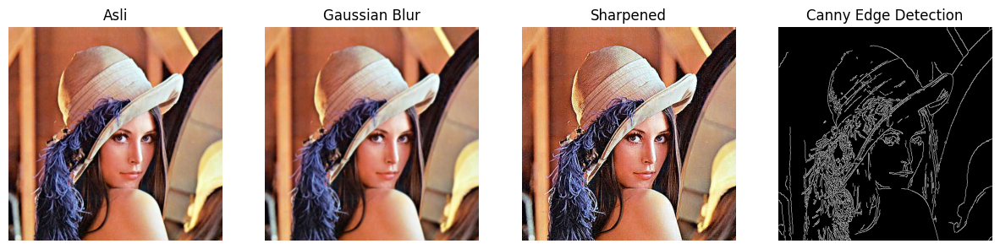

In [10]:
def show_side_by_side(images, titles, figsize=(15,5)):
    plt.figure(figsize=figsize)
    for i, (img, title) in enumerate(zip(images, titles)):
        if len(img.shape) == 2:  # grayscale
            plt.subplot(1, len(images), i+1)
            plt.imshow(img, cmap="gray")
        else:  # color
            plt.subplot(1, len(images), i+1)
            plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
        plt.title(title)
        plt.axis("off")
    plt.show()

img = cv.imread("/content/drive/MyDrive/pcvk_vanesa/Images/lena.jpg")
img_gray = cv.cvtColor(img,cv.COLOR_BGR2GRAY)

blur = cv.GaussianBlur(img, (7,7), 1)
edges = cv.Canny(cv.cvtColor(img, cv.COLOR_BGR2GRAY), 100, 200)
sharpen_kernel = np.array([[0,-1,0],[-1,5,-1],[0,-1,0]])
sharpened = cv.filter2D(img, -1, sharpen_kernel)
show_side_by_side([img, blur, sharpened, edges],
                  ["Asli", "Gaussian Blur", "Sharpened", "Canny Edge Detection"])

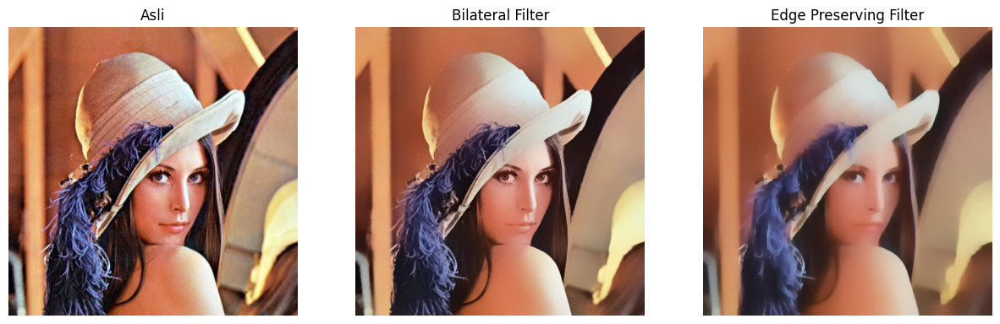

In [11]:
bilateral = cv.bilateralFilter(img, 50, 100, 100)

edge_preserve = cv.edgePreservingFilter(img, flags=1, sigma_s=100, sigma_r=0.9)

show_side_by_side([img, bilateral, edge_preserve],
                  ["Asli", "Bilateral Filter", "Edge Preserving Filter"])

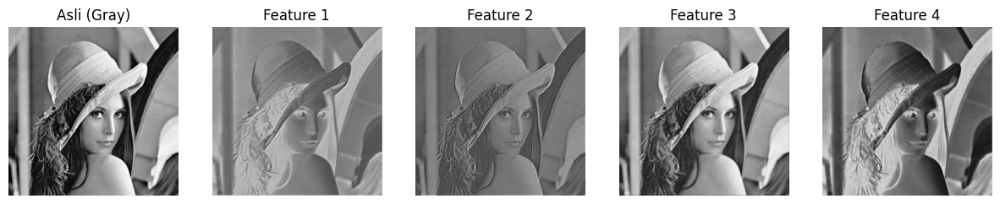

In [12]:
import torch
import torch.nn as nn

class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 4, kernel_size=3, stride=1, padding=1)

    def forward(self, x):
        return self.conv1(x)

model = SimpleCNN()

# Ubah gambar ke tensor
img_tensor = torch.tensor(img_gray, dtype=torch.float32).unsqueeze(0).unsqueeze(0) / 255.0

# Hasil CNN
with torch.no_grad():
    features = model(img_tensor)

# Visualisasi feature maps
feature_maps = [features[0,i].numpy() for i in range(features.shape[1])]
show_side_by_side([img_gray] + feature_maps, ["Asli (Gray)"] + [f"Feature {i+1}" for i in range(len(feature_maps))])

Jawaban percobaan 3 :
1. Setiap kode dijalankan, hasil feature 1 sampai 4 selalu berubah. Penyebabnya, bobot kernel di nn.Conv2d diisi acak saat model dibuat dan belum dilatih. Jadi ada feature map yang mirip filter deteksi tepi (garis-garis jelas), ada yang mirip blur, ada juga yang cuma mengubah kontras atau kecerahan. Ini menunjukkan CNN itu pada dasarnya kumpulan filter konvolusi seperti kernel di modul (Sobel, sharpen, dll). Bedanya, nilai kernelnya tidak ditentukan manual, tapi dipelajari lewat proses training supaya menangkap fitur yang berguna.

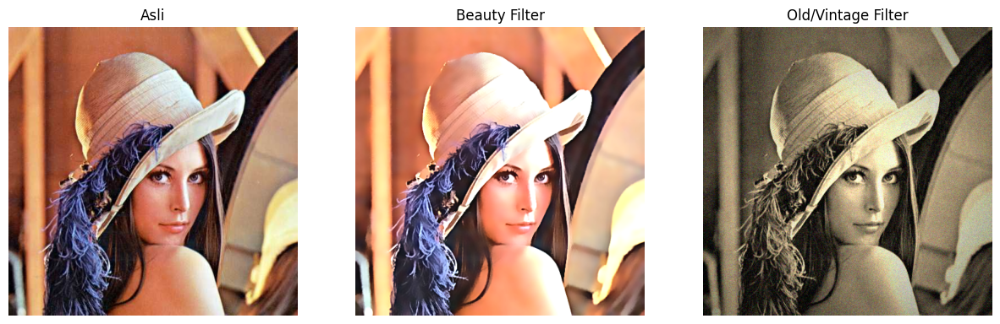

In [15]:
smooth = cv.bilateralFilter(img, d=15, sigmaColor=75, sigmaSpace=75)

gaussian = cv.GaussianBlur(smooth, (0,0), 3)
sharpened = cv.addWeighted(smooth, 1.5, gaussian, -0.5, 0)

alpha = 1.2
beta = 15
beauty = cv.convertScaleAbs(sharpened, alpha=alpha, beta=beta)


sepia_kernel = np.array([[0.272, 0.534, 0.131],
                         [0.349, 0.686, 0.168],
                         [0.393, 0.769, 0.189]])
sepia = cv.transform(img, sepia_kernel)
sepia = np.clip(sepia, 0, 255).astype(np.uint8)

rows, cols = img.shape[:2]
kernel_x = cv.getGaussianKernel(cols, cols*0.6)
kernel_y = cv.getGaussianKernel(rows, rows*0.6)
kernel = kernel_y * kernel_x.T
mask = kernel / kernel.max()
vignette = np.copy(sepia)
for i in range(3):
    vignette[:,:,i] = vignette[:,:,i] * mask

noise = np.random.normal(0, 15, vignette.shape).astype(np.int16)
old_img = np.clip(vignette.astype(np.int16) + noise, 0, 255).astype(np.uint8)
show_side_by_side([img, beauty, old_img], ["Asli", "Beauty Filter", "Old/Vintage Filter"])

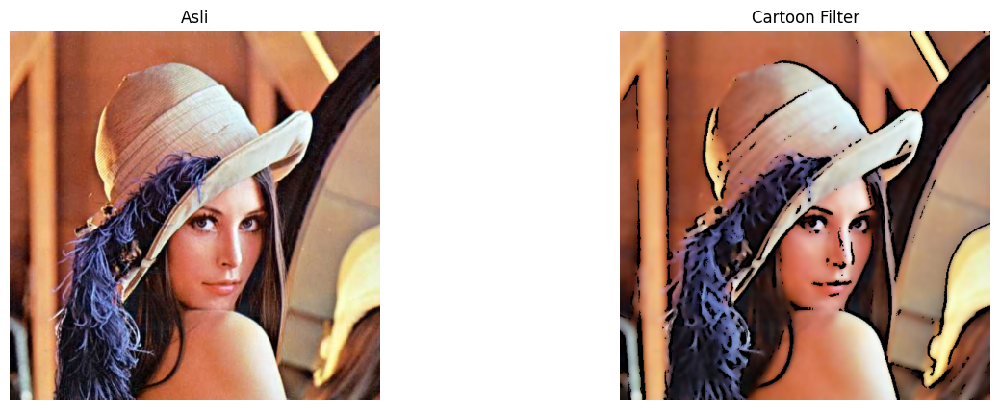

In [16]:
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
gray_blur = cv.medianBlur(gray, 7)
edges = cv.adaptiveThreshold(gray_blur, 255,
                             cv.ADAPTIVE_THRESH_MEAN_C,
                             cv.THRESH_BINARY, 9, 9)

color = cv.bilateralFilter(img, d=9, sigmaColor=200, sigmaSpace=200)

cartoon = cv.bitwise_and(color, color, mask=edges)

show_side_by_side([img, cartoon], ["Asli", "Cartoon Filter"])

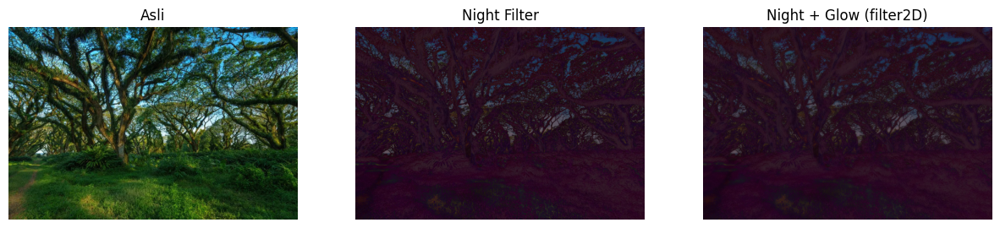

In [17]:
img = cv.imread("/content/drive/MyDrive/pcvk_vanesa/Images/djawatan.jpg")
img_gray = cv.cvtColor(img,cv.COLOR_BGR2GRAY)

night = cv.convertScaleAbs(img, alpha=0.6, beta=-40)

blue_tint = np.full_like(night, (50, 0, 100))  # BGR
night = cv.addWeighted(night, 0.8, blue_tint, 0.2, 0)

kernel = np.ones((15,15), np.float32) / 225
glow = cv.filter2D(night, -1, kernel)

night_glow = cv.addWeighted(night, 0.7, glow, 0.3, 0)

show_side_by_side([img, night, night_glow],
                  ["Asli", "Night Filter", "Night + Glow (filter2D)"])

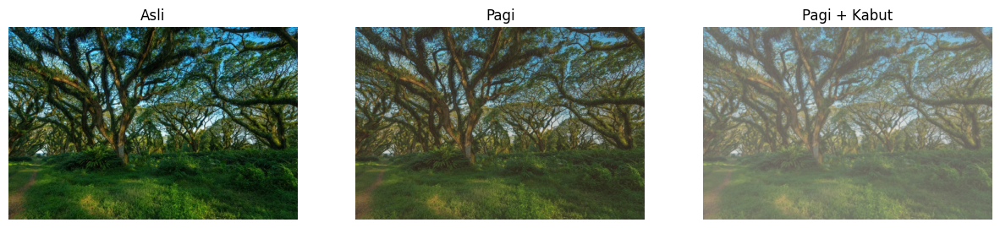

In [18]:
alpha = 0.9
beta = 20
soft = cv.convertScaleAbs(img, alpha=alpha, beta=beta)

warm_tint = np.full_like(soft, (40, 70, 120))  # BGR
pagi = cv.addWeighted(soft, 0.8, warm_tint, 0.2, 0)

kernel = cv.getGaussianKernel(3, 3)
kernel = kernel @ kernel.T  # jadikan 2D kernel
kabut = cv.filter2D(pagi, -1, kernel)


white_layer = np.full_like(pagi, 255)
kabut = cv.addWeighted(kabut, 0.7, white_layer, 0.3, 0)

show_side_by_side([img, pagi, kabut],
                  ["Asli", "Pagi", "Pagi + Kabut"])

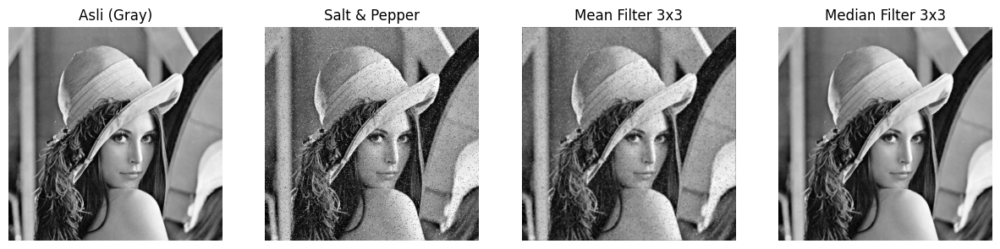

In [19]:
img = cv.imread("/content/drive/MyDrive/pcvk_vanesa/Images/lena.jpg")
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

# a. Tambahkan noise salt and pepper
noisy = img_gray.copy()
jumlah = int(0.05 * noisy.size)
baris = np.random.randint(0, noisy.shape[0], jumlah)
kolom = np.random.randint(0, noisy.shape[1], jumlah)
noisy[baris[:jumlah//2], kolom[:jumlah//2]] = 255   # salt (putih)
noisy[baris[jumlah//2:], kolom[jumlah//2:]] = 0     # pepper (hitam)

# b. Mean Filter 3x3 dan Median Filter 3x3
kernel_mean = np.ones((3,3)) / 9
mean_hasil = convolution2d(noisy, kernel_mean, 1, 1)
median_hasil = cv.medianBlur(noisy, 3)

show_side_by_side([img_gray, noisy, mean_hasil, median_hasil],
                  ["Asli (Gray)", "Salt & Pepper", "Mean Filter 3x3", "Median Filter 3x3"])

Jawaban 1c (analisis):
Mean filter menghitung rata-rata semua piksel di jendela 3x3. Nilai noise yang ekstrem (0 atau 255) ikut masuk hitungan, jadi bintik hitam-putihnya nggak hilang, cuma menyebar jadi bercak abu-abu yang buram dan ujungnya ikut ngeblur. Median filter beda: 9 nilai di jendela diurutkan dulu, lalu diambil nilai tengahnya. Karena piksel noise pasti berada di ujung urutan (paling kecil atau paling besar), nilainya langsung terbuang dan tidak terpilih. Makanya bintiknya hilang bersih, dan tepi objek juga lebih terjaga. Selama noise-nya nggak terlalu padat (kurang dari setengah isi jendela), median jauh lebih bagus untuk salt and pepper.

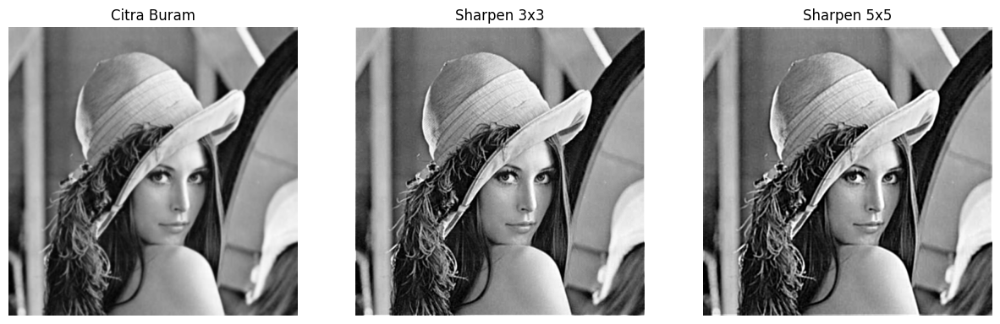

In [20]:
# Citra yang sedikit buram
blurry = cv.GaussianBlur(img_gray, (7,7), 1)

# a. Kernel sharpening 3x3 dan 5x5
kernel_3x3 = np.array([[0,-1,0],
                       [-1,5,-1],
                       [0,-1,0]])
kernel_5x5 = np.array([[-1,-1,-1,-1,-1],
                       [-1,2,2,2,-1],
                       [-1,2,8,2,-1],
                       [-1,2,2,2,-1],
                       [-1,-1,-1,-1,-1]]) / 8

# b. Terapkan pada citra buram
sharp_3x3 = convolution2d(blurry, kernel_3x3, 1, 1)
sharp_5x5 = convolution2d(blurry, kernel_5x5, 1, 2)

show_side_by_side([blurry, sharp_3x3, sharp_5x5],
                  ["Citra Buram", "Sharpen 3x3", "Sharpen 5x5"])

Jawaban 2c (evaluasi):
Dari hasil percobaan, Sharpen 3x3 menghasilkan tepi yang paling jelas: tekstur rambut, garis topi, dan kontur wajah terlihat lebih tegas dibanding citra buram. Sharpen 5x5 juga menajamkan citra, tapi efeknya lebih lemah dan hasilnya masih agak lembut, selain itu muncul garis tipis terang di bagian pinggir citra karena jendela yang lebih besar melewati batas citra (efek border). Kernel 5x5 juga butuh komputasi lebih berat karena tiap piksel menghitung 25 perkalian, bukan 9. Jadi untuk penggunaan sehari-hari, kernel 3x3 paling optimal: tepinya paling jelas, distorsi di pinggir kecil, dan prosesnya lebih ringan. Kernel 5x5 baru berguna kalau citranya sangat buram dan butuh penajaman yang lebih luas.

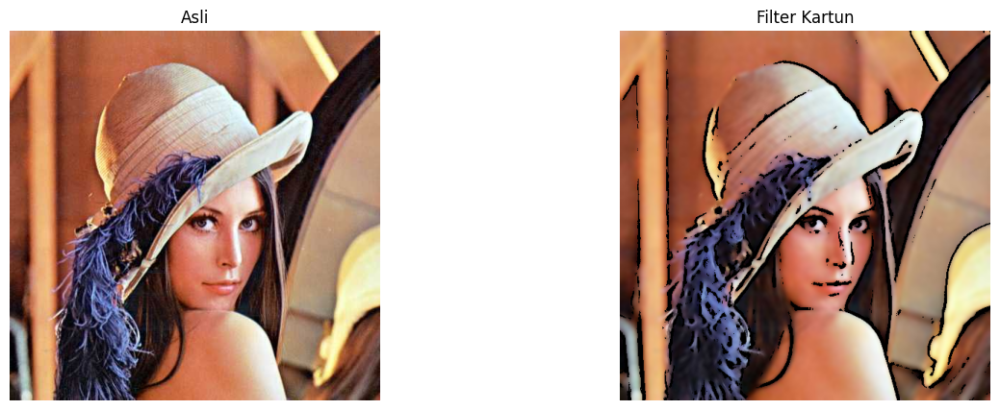

In [21]:
def kartun(image):
    # Deteksi garis tepi dengan Adaptive Thresholding
    gray = cv.cvtColor(image, cv.COLOR_BGR2GRAY)
    gray_blur = cv.medianBlur(gray, 7)
    edges = cv.adaptiveThreshold(gray_blur, 255,
                                 cv.ADAPTIVE_THRESH_MEAN_C,
                                 cv.THRESH_BINARY, 9, 9)

    # Penghalusan warna dengan Bilateral Filter
    color = cv.bilateralFilter(image, d=9, sigmaColor=200, sigmaSpace=200)

    # Gabungkan keduanya dengan operasi logika (bitwise AND)
    hasil = cv.bitwise_and(color, color, mask=edges)
    return hasil

show_side_by_side([img, kartun(img)], ["Asli", "Filter Kartun"])